In [1]:
import pandas as pd
import numpy as np

In [2]:
data_df = pd.read_csv("https://www.statlearning.com/s/Advertising.csv", index_col = 0)
data_df.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


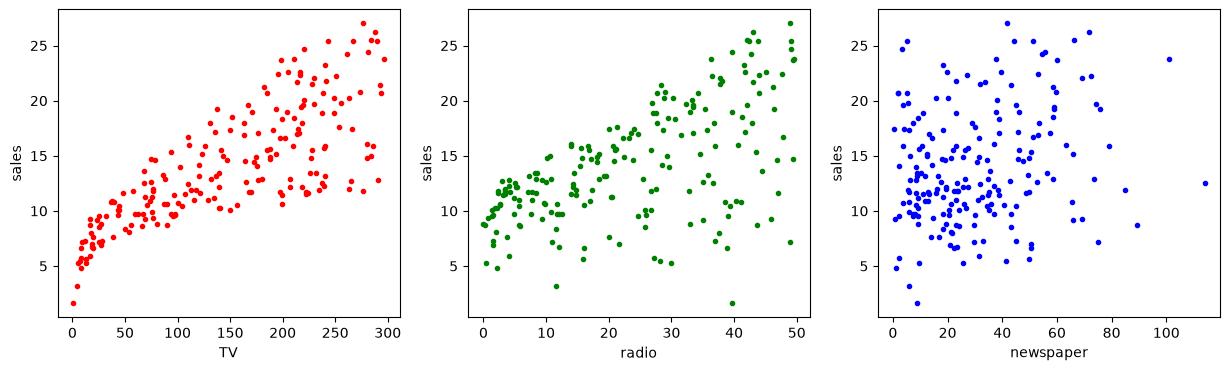

In [3]:
import matplotlib as mpl
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(15,4))
gs = mpl.gridspec.GridSpec(1,3)

# Plot of sales vs TV
ax = fig.add_subplot(gs[0])
ax.scatter(data_df["TV"], data_df["sales"], color="red", marker=".")
ax.set_xlabel("TV")
ax.set_ylabel("sales")

# Plot of sales vs radio
ax = fig.add_subplot(gs[1])
ax.scatter(data_df["radio"], data_df["sales"], color="green", marker=".")
ax.set_xlabel("radio")
ax.set_ylabel("sales")

# Plot of sales vs newspaper
ax = fig.add_subplot(gs[2])
ax.scatter(data_df["newspaper"], data_df["sales"], color="blue", marker=".")
ax.set_xlabel("newspaper")
ax.set_ylabel("sales")

plt.show()

The first plot shows a sharp upward trend in the number of units sold as TV advertising increases. A similar trend is also found as radio advertising increases. However, in the last plot, there does not appear to be a relationship between newspaper advertising and the number of units sold.

--

$$\hat{\beta_1} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}$$

$$\hat{\beta_0} = \bar{y} - \beta_1\bar{x}$$
From the samples provided, first we find $\beta_1$ from the first expression and substitute the value of $\beta_1$ in the second expression for $\beta_0$.

In [4]:
X = data_df.TV.to_numpy()
y = data_df.sales.to_numpy()

In [5]:
# Calculating beta_1
x_mean = X.mean()
y_mean = y.mean()

beta_1 = np.sum((X - x_mean) * (y - y_mean)) / np.sum(np.power((X - x_mean), 2))

print(beta_1)

0.047536640433019736


In [6]:
# Calculating beta_0

beta_0 = y_mean - ( beta_1 * x_mean)

print(beta_0)

7.0325935491276965


In [7]:
# Best Fit Line Equation
print(f" y = {beta_0:.3f} + {beta_1:.3f} x")

 y = 7.033 + 0.048 x


In [11]:
# Calculating SSE
y_hat = beta_0 + ( beta_1 * X)

SSE = np.sum((y - y_hat) ** 2)
print(SSE)

2102.5305831313512


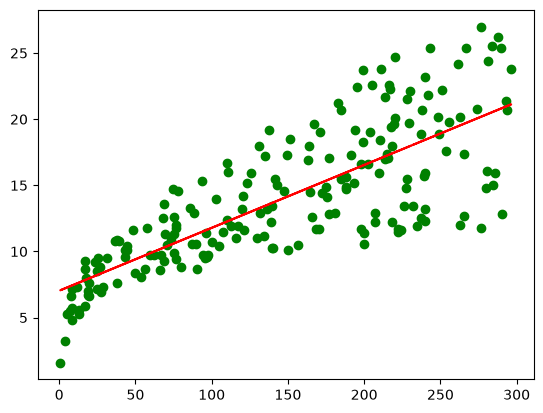

In [13]:
plt.scatter(X,y,color = "green")
plt.plot(X, beta_0+(beta_1 * X), color = "red")

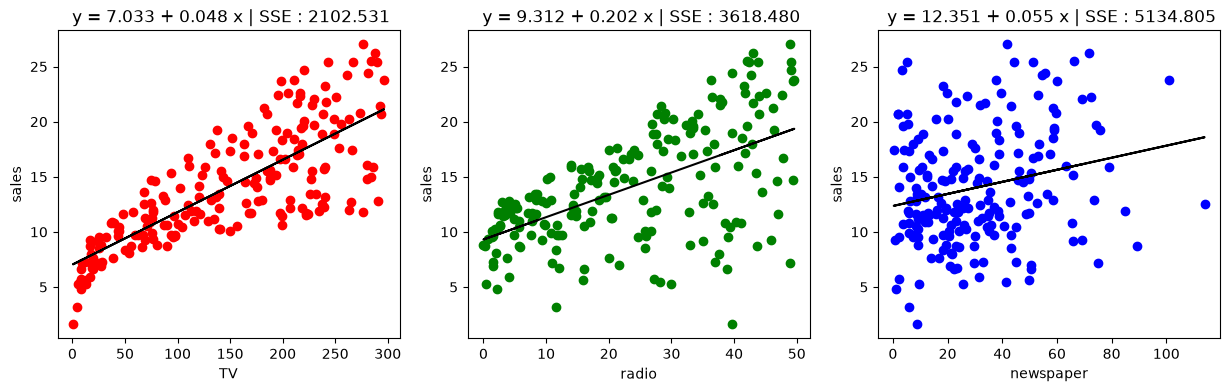

In [14]:
import matplotlib as mpl
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(15,4))
gs = mpl.gridspec.GridSpec(1,3)

def train_plot(data_df, feature, ax, c):
    X = data_df[feature].to_numpy()
    y = data_df.sales.to_numpy()
    # Calculating beta_1
    x_mean = X.mean()
    y_mean = y.mean()
    beta_1 = np.sum((X - x_mean) * (y - y_mean)) / np.sum(np.power((X - x_mean), 2))
    # Calculating beta_0
    beta_0 = y_mean - ( beta_1 * x_mean)
    
    y_hat = beta_0 + np.dot(X, beta_1)
    SSE = np.sum(np.power((y - y_hat), 2))
    
    # Plot Regression Line
    ax.scatter(X, y, color = c)
    ax.plot(X, y_hat, color = "black")
    ax.set_xlabel(feature)
    ax.set_ylabel("sales")
    ax.set_title(f" y = {beta_0:.3f} + {beta_1:.3f} x | SSE : {SSE:.3f}")

# Plot of sales vs TV
ax0 = fig.add_subplot(gs[0])
train_plot(data_df, "TV", ax0, "red")

# Plot of sales vs radio
ax1 = fig.add_subplot(gs[1])
train_plot(data_df, "radio", ax1, "green")

# Plot of sales vs newspaper
ax2 = fig.add_subplot(gs[2])
train_plot(data_df, "newspaper", ax2, "blue")

plt.show()

## Sklearn Implementation

In [15]:
from sklearn.linear_model import LinearRegression

In [17]:
X = data_df.TV.to_numpy()
y = data_df.sales.to_numpy()

linear_reg = LinearRegression()

In [19]:
linear_reg.fit(X.reshape(-1,1), y.reshape(-1,1))

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.05]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[7.03]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1211.12]


In [20]:
# beta_0
linear_reg.intercept_

array([7.03259355])

In [21]:
# beta_1
linear_reg.coef_

array([[0.04753664]])

In [22]:
y_cap = linear_reg.predict(X.reshape(-1,1))

In [24]:
SSE = np.sum(np.power((y - y_cap.flatten()), 2))
print(SSE)

2102.5305831313512
